In [1]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
import pickle
import corner
import pandas as pd
import tensorflow as tf
from scipy.stats import gaussian_kde

2026-02-25 17:24:46.632189: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 17:24:54.298305: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# define your plot style

best_style = {
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (10.0, 10.0),
    "font.size": 26,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    "legend.fontsize": "small",
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(best_style)
cols = ["#5790fc", "#f89c20", "#009e73", "#e42536", "#9c9ca1", "#964a8b",  "#7a21dd"]
# add a new color blind friendly color to this list
#set cols as the matplotlib default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cols)

In [3]:
model_name = "entire_region_narrowprior"
model_path = '/deepskieslab/stronglensing/hsbi/models/'
model = tf.keras.models.load_model(model_path + model_name + '.keras')

2026-02-25 17:26:04.470764: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-25 17:26:07.589040: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-25 17:26:07.589756: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [40]:
save_filepath = '/home/jarugula/nre_wom/proj_cosmo_nre/src/scripts/evaluate/mcmc/plots/'

In [4]:
datadir = "region2_narrowprior"

image_dir = f'/deepskieslab/stronglensing/hsbi/datasets/test_data/{datadir}/data_0'
images = np.load(image_dir + '/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata = pd.read_csv(image_dir + '/CONFIGURATION_1_metadata.csv')

In [5]:
w_column_name = "w0-g" # Dark energy equation-of-state parameter 
om_column_name = 'Om0-g'
zl_column_name = 'PLANE_1-REDSHIFT-g'
zs_column_name = 'PLANE_2-REDSHIFT-g'
v_column_name = 'PLANE_1-OBJECT_1-MASS_PROFILE_1-sigma_v-g'

In [6]:
images = np.einsum('lkij->lijk', images)
print(images.shape)
aparms = metadata[[zl_column_name,zs_column_name,v_column_name]].to_numpy().astype(np.float32)

(100, 32, 32, 1)


In [7]:
edge_size = images.shape[1]
images = edge_size * edge_size * (images / np.sum(images, axis=(1, 2), keepdims=True))
images = images.reshape(images.shape[0], -1)
images = images.reshape(images.shape[0], edge_size, edge_size, 1)

In [8]:
# return true values
true_w = metadata[w_column_name].unique()[0]
true_om = metadata[om_column_name].unique()[0]

print(true_w, true_om)

-0.9895467391672544 0.3289012922760826


## MCMC

In [9]:
def get_logr_mcmc(model, images, aparam, sample_theta):
    ''''
    Function to predict the log likelihood-to-evidence ratio (logr) of all the test data at a time

    Input:
    model: The trained model 
    images: test images
    sample_theta: a list of theta values to compute logr for

    Output:
    log r 
    '''
    theta_array = np.array([sample_theta]*images.shape[0])
    output = model.predict([images, aparam, theta_array], verbose=0).flatten()
    return output

def log_prior(theta, w_low=-1.5, w_high=-0.5, om_low=0.1, om_high=0.5):
    """
    prior for w, om
    """
    w, om = theta
    if w_low < w < w_high and om_low < om < om_high:
        return 0.0
    return -np.inf

def log_likelihood(theta, data, aparam, w_low, w_high, om_low, om_high, model, calibrate):
    """
    Calculate the log likelihood + log prior
    """
    lp = log_prior(theta, w_low, w_high, om_low, om_high)
    if not np.isfinite(lp):
        return -np.inf
    logr_array = get_logr_mcmc(model, data, aparam, theta)
    if calibrate:
        alpha = 0.175255
        beta = 0.11896
        ll = alpha*np.sum(logr_array) + beta
    else:
        ll = np.sum(logr_array)
    return lp + ll

In [10]:
initial_w=-1.0
initial_om=0.3
walkers=5
nsteps=1000
nburn=200

ommin = 0.1
ommax = 0.9
wmin = -1.8
wmax = -0.4

n_images = [1, 20, 50, 100]

In [11]:
# # without calibration
# pos = np.array([initial_w, initial_om]) + np.array([initial_w, initial_om]) * 1e-3 * np.random.randn(walkers, 2)
# nwalkers, ndim = pos.shape

# calibrate = False
# flat_samples_list = []

# for n_img in n_images:
#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(images[:n_img], aparms[:n_img], wmin, wmax, ommin, ommax, model, calibrate))
#     print("Running first burn-in...")
#     pos, lp, _ = sampler.run_mcmc(pos, nburn, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     print("Running production...")
#     pos = pos[np.argmax(lp)] + 1e-4 * np.random.randn(nwalkers, ndim)
#     sampler.reset()
#     pos, lp, _ = sampler.run_mcmc(pos, nsteps, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     flat_samples = sampler.get_chain(discard=int(nsteps / 4), flat=True)
#     flat_samples_list.append(flat_samples)

# # save the flat samples without calibration
# with open('flat_samples_population_no_calibrate.pkl', 'wb') as f:
#     pickle.dump(flat_samples_list, f)

In [12]:
# read the flat samples without calibration
with open('flat_samples_population_no_calibrate.pkl', 'rb') as f:
    flat_samples_list = pickle.load(f)

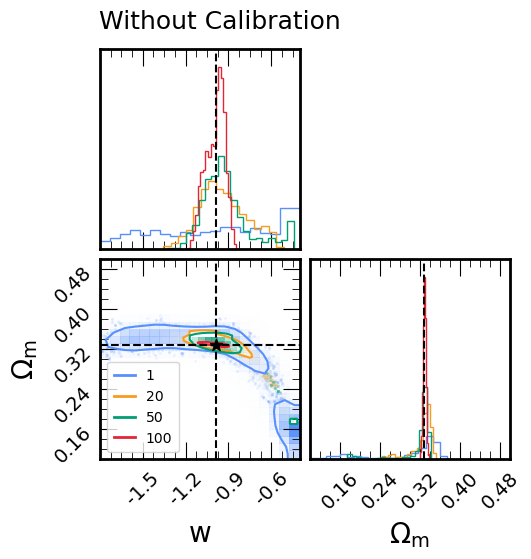

In [41]:
x_min = -1.8
x_max = -0.4
y_min = 0.1
y_max = 0.5

fig = corner.corner(flat_samples_list[0], labels=[ r"$w$", r"$\Omega_{m}$"], 
                    color=cols[0], hist_kwargs={'density':True}, alpha=0.1, plot_contours=True, 
                    levels=[0.682], smooth=1.0)
for i in range(1, len(n_images)):
    corner.corner(flat_samples_list[i], fig=fig,
                labels=[r"$w$", r"$\Omega_{m}$"], 
                        color=cols[i], hist_kwargs={'density':True}, alpha=0.1, plot_contours=True, 
                        levels=[0.682], smooth=1.0)
for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel(ax.get_xlabel(), fontsize=20)
    ax.set_ylabel(ax.get_ylabel(), fontsize=20) 

axes = np.array(fig.axes).reshape((2, 2))
axes[0, 0].axvline(true_w, linestyle='--', color='k', lw=1.5)
axes[1, 1].axvline(true_om, linestyle='--', color='k', lw=1.5)
axes[1, 0].scatter(true_w, true_om, color='k', s=80, marker="*", zorder=10)
axes[1, 0].axhline(true_om, linestyle='--', color='k', lw=1.5)
axes[1, 0].axvline(true_w, linestyle='--', color='k', lw=1.5)

# set limits
axes[0,0].set_xlim(x_min, x_max)
axes[1,1].set_xlim(y_min, y_max)
axes[1,0].set_xlim(x_min, x_max)
axes[1,0].set_ylim(y_min, y_max)

# add titlee without calibration
fig.suptitle('Without Calibration', fontsize=18, y=1.0, x=0.4)

# add legend for different n_images as lines
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cols[i], lw=2, label=f'{n_images[i]}') for i in range(len(n_images))]
axes[1, 0].legend(handles=legend_elements, loc='lower left', fontsize=10)

plt.savefig(save_filepath + 'population_posteriors_no_calibrate.pdf', dpi=300)
plt.show()

In [42]:
# plot the median and 68% credible intervals for w and om as a function of n_images
# modify this code to plot in one column and two rows with shared X axis as number of images.
# label the Y axis as $w$ and $\Omega_{m}$ respectively. Add a horizontal line for the true value of w and om. Add a title for each subplot as "Posterior of $w$ vs Number of Images" and "Posterior of $\Omega_{m}$ vs Number of Images". Add a legend for the true value lines.
def plot_population_posteriors(flat_samples_list, n_images, save_filename = None):
    w_medians = []
    w_lower = []
    w_upper = []
    om_medians = []
    om_lower = []
    om_upper = []

    for samples in flat_samples_list:
        w_samples = samples[:, 0]
        om_samples = samples[:, 1]

        w_medians.append(np.median(w_samples))
        w_lower.append(np.percentile(w_samples, 16))
        w_upper.append(np.percentile(w_samples, 84))

        om_medians.append(np.median(om_samples))
        om_lower.append(np.percentile(om_samples, 16))
        om_upper.append(np.percentile(om_samples, 84))

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
    axes[0].errorbar(n_images, w_medians, yerr=[np.array(w_medians) - np.array(w_lower), np.array(w_upper) - np.array(w_medians)], fmt='o', color=cols[2], label='Predicted $w$')
    axes[0].axhline(true_w, color='k', linestyle='--', label='True $w$')
    axes[0].set_ylabel('$w$')
    # axes[0].set_title('Posterior of $w$ vs Number of Images')
    axes[0].legend(loc='lower right', fontsize=20)    
    axes[1].errorbar(n_images, om_medians, yerr=[np.array(om_medians) - np.array(om_lower), np.array(om_upper) - np.array(om_medians)], fmt='o', color=cols[5], label='Predicted $\Omega_{m}$')
    axes[1].axhline(true_om, color='k', linestyle='--', label='True $\Omega_{m}$')
    axes[1].set_xlabel('Number of Images')
    axes[1].set_ylabel('$\Omega_{m}$')
    # axes[1].set_title('Posterior of $\Omega_{m}$ vs Number of Images')
    axes[1].legend(loc='lower right', fontsize=20)
    plt.tight_layout()
    if save_filename is not None:
        plt.savefig(save_filename, dpi=300)
    # plt.show()

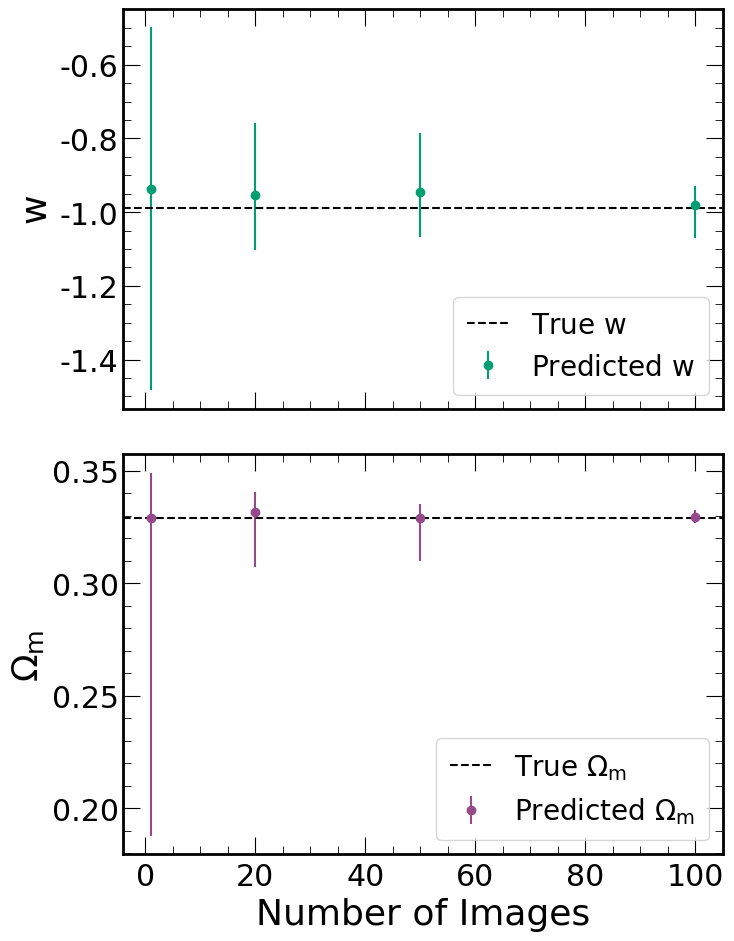

In [43]:
_ = plot_population_posteriors(flat_samples_list, n_images, save_filename=save_filepath + 'population_posteriors_no_calibrate.pdf')

In [36]:
# # with calibration
# pos = np.array([initial_w, initial_om]) + np.array([initial_w, initial_om]) * 1e-3 * np.random.randn(walkers, 2)
# nwalkers, ndim = pos.shape

# calibrate = True
# flat_samples_calibrate_list = []

# n_images = [1, 20, 50, 100]

# for n_img in n_images:
#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(images[:n_img], aparms[:n_img], wmin, wmax, ommin, ommax, model, calibrate))
#     print("Running first burn-in...")
#     pos, lp, _ = sampler.run_mcmc(pos, nburn, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     print("Running production...")
#     pos = pos[np.argmax(lp)] + 1e-4 * np.random.randn(nwalkers, ndim)
#     sampler.reset()
#     pos, lp, _ = sampler.run_mcmc(pos, nsteps, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     flat_samples = sampler.get_chain(discard=int(nsteps / 4), flat=True)
#     flat_samples_calibrate_list.append(flat_samples)

# # save the flat samples with calibration
# with open('flat_samples_population_calibrate.pkl', 'wb') as f:
#     pickle.dump(flat_samples_calibrate_list, f)

In [37]:
# read the flat samples with calibration
with open('flat_samples_population_calibrate.pkl', 'rb') as f:
    flat_samples_calibrate_list = pickle.load(f)

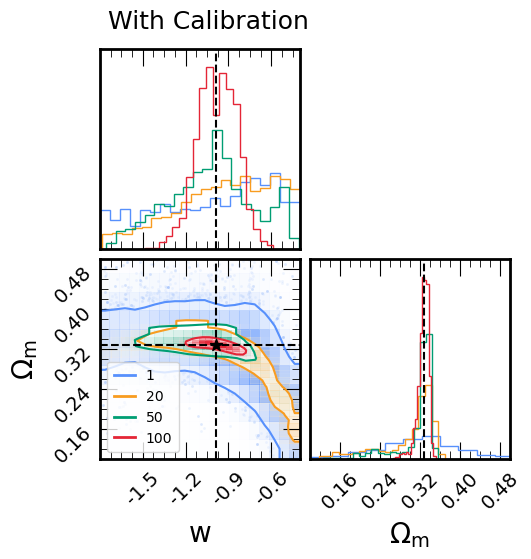

In [44]:
x_min = -1.8
x_max = -0.4
y_min = 0.1
y_max = 0.5

fig = corner.corner(flat_samples_calibrate_list[0], labels=[ r"$w$", r"$\Omega_{m}$"], 
                    color=cols[0], hist_kwargs={'density':True}, alpha=0.1, plot_contours=True, 
                    levels=[0.682], smooth=1.0)
for i in range(1, len(n_images)):
    corner.corner(flat_samples_calibrate_list[i], fig=fig,
                labels=[r"$w$", r"$\Omega_{m}$"], 
                        color=cols[i], hist_kwargs={'density':True}, alpha=0.1, plot_contours=True, 
                        levels=[0.682],smooth=1.0)
for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel(ax.get_xlabel(), fontsize=20)
    ax.set_ylabel(ax.get_ylabel(), fontsize=20) 

axes = np.array(fig.axes).reshape((2, 2))
axes[0, 0].axvline(true_w, linestyle='--', color='k', lw=1.5)
axes[1, 1].axvline(true_om, linestyle='--', color='k', lw=1.5)
axes[1, 0].scatter(true_w, true_om, color='k', s=80, marker="*", zorder=10)
axes[1, 0].axhline(true_om, linestyle='--', color='k', lw=1.5)
axes[1, 0].axvline(true_w, linestyle='--', color='k', lw=1.5)

# set limits
axes[0,0].set_xlim(x_min, x_max)
axes[1,1].set_xlim(y_min, y_max)
axes[1,0].set_xlim(x_min, x_max)    
axes[1,0].set_ylim(y_min, y_max)

# add titlee without calibration
fig.suptitle('With Calibration', fontsize=18, y=1.0, x=0.38)

# add legend for different n_images as lines
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cols[i], lw=2, label=f'{n_images[i]}') for i in range(len(n_images))]
axes[1, 0].legend(handles=legend_elements, loc='lower left', fontsize=10)

plt.savefig(save_filepath + 'population_posteriors_calibrate.pdf', dpi=300)
# plt.show()


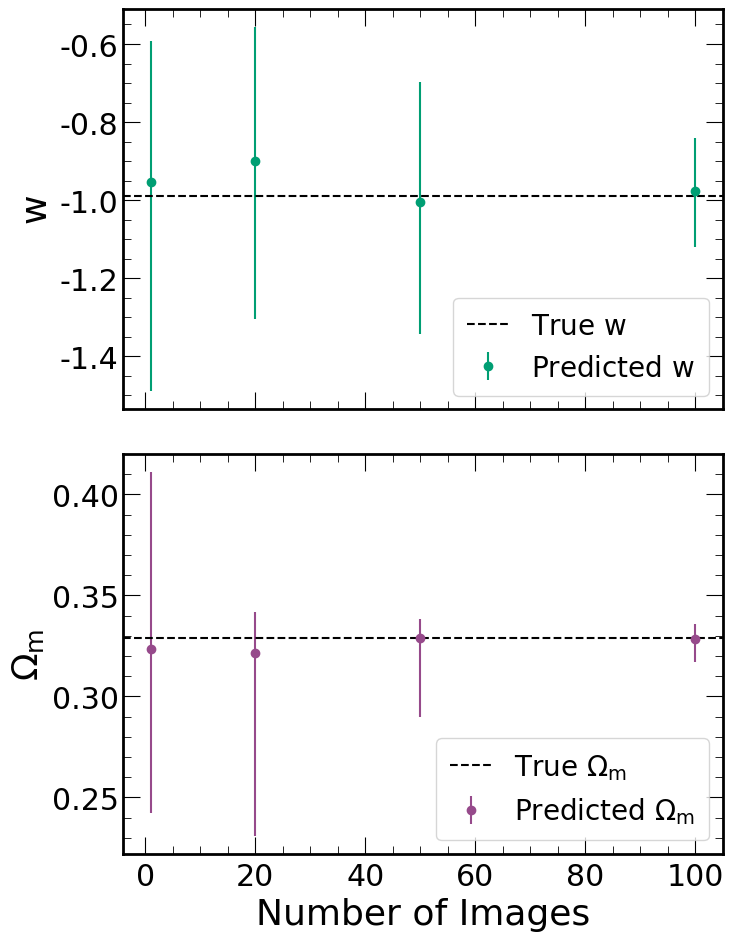

In [45]:
_ = plot_population_posteriors(flat_samples_calibrate_list, n_images, save_filename=save_filepath + 'population_posteriors_calibrate.pdf' )